<a href="https://colab.research.google.com/github/AswiniNaresh/MachineLearning/blob/main/Medical_Insurance_Cost_Predicition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import os
from sklearn import preprocessing
from scipy.stats import skew
import plotly.express as px
from google.colab import drive
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score,mean_absolute_error

In [ ]:
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/MyDrive/medical_insurance.csv')

In [ ]:
#EDA

In [ ]:
df.head() ##To view first five record

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [ ]:
df.tail() #To view last five record

,age,sex,bmi,children,smoker,region,charges
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229
2771,54,male,31.600,0,no,southwest,9850.43200


In [ ]:
df.info() #To get the datatype and not null details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,2772.0,39.109668,14.081459,18.0000,26.000,39.00000,51.0000,64.00000
bmi,2772.0,30.701349,6.129449,15.9600,26.220,30.44750,34.7700,53.13000
children,2772.0,1.101732,1.214806,0.0000,0.000,1.00000,2.0000,5.00000
charges,2772.0,13261.369959,12151.768945,1121.8739,4687.797,9333.01435,16577.7795,63770.42801


In [ ]:
df.isnull().sum() #To check the missing values

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [ ]:
df.duplicated().sum() #Removing duplicate values

1435

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.count()

age         1337
sex         1337
bmi         1337
children    1337
smoker      1337
region      1337
charges     1337
dtype: int64

In [ ]:
df.shape

(1337, 7)

In [ ]:
#Visualizations
#Feature Visualization

In [ ]:
#Bivariate with feature - Sex and Targett - Charges

#fig=px.bar(df, x='sex',y='charges')
#fig.show()

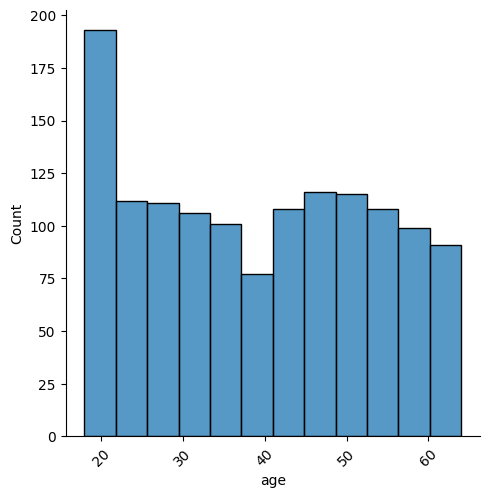

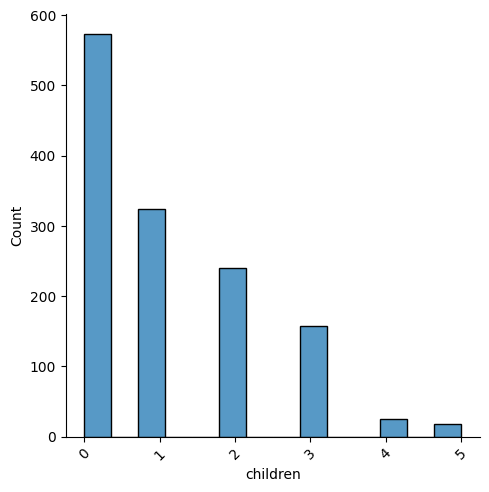

In [ ]:
numeric_columns=df.select_dtypes(include=['int64'])
for col in numeric_columns:
    sb.displot(x=df[col],data=df)
    plt.xticks(rotation=45)
    plt.show()

<ipython-input-8-c4c319f9c3a5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


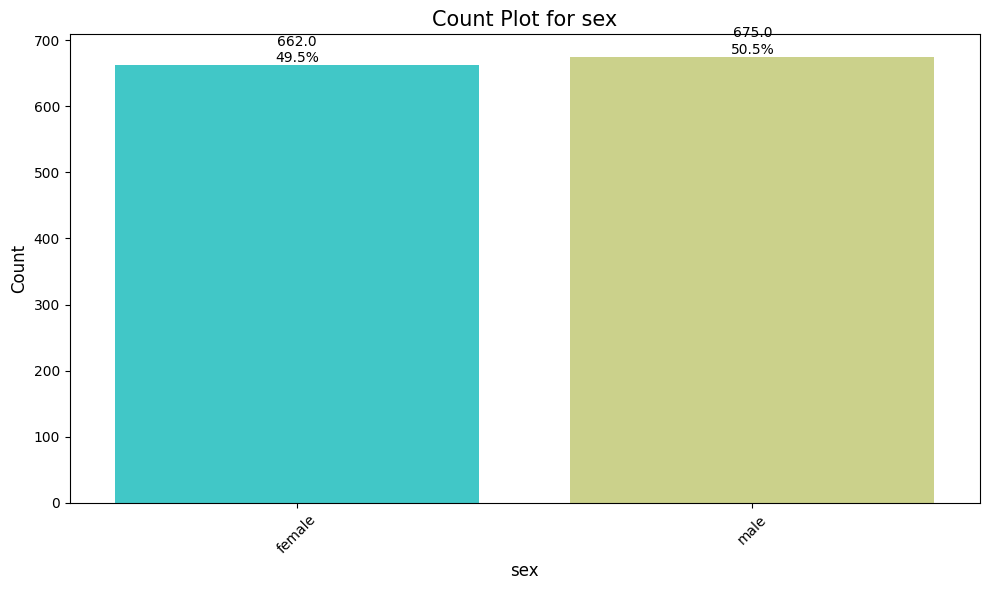

<ipython-input-8-c4c319f9c3a5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


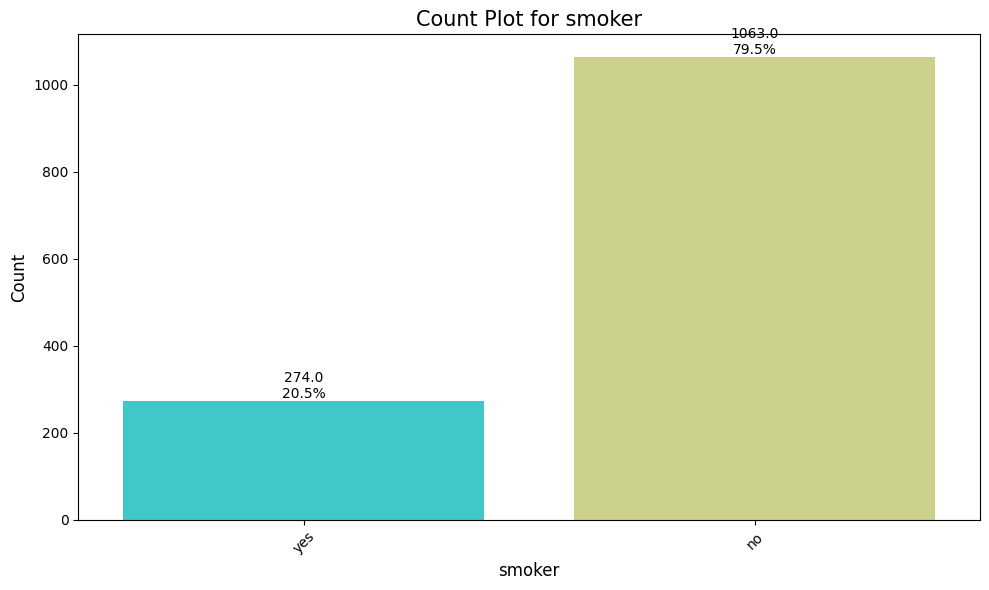

<ipython-input-8-c4c319f9c3a5>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sb.countplot(x=column, data=df,palette='rainbow')


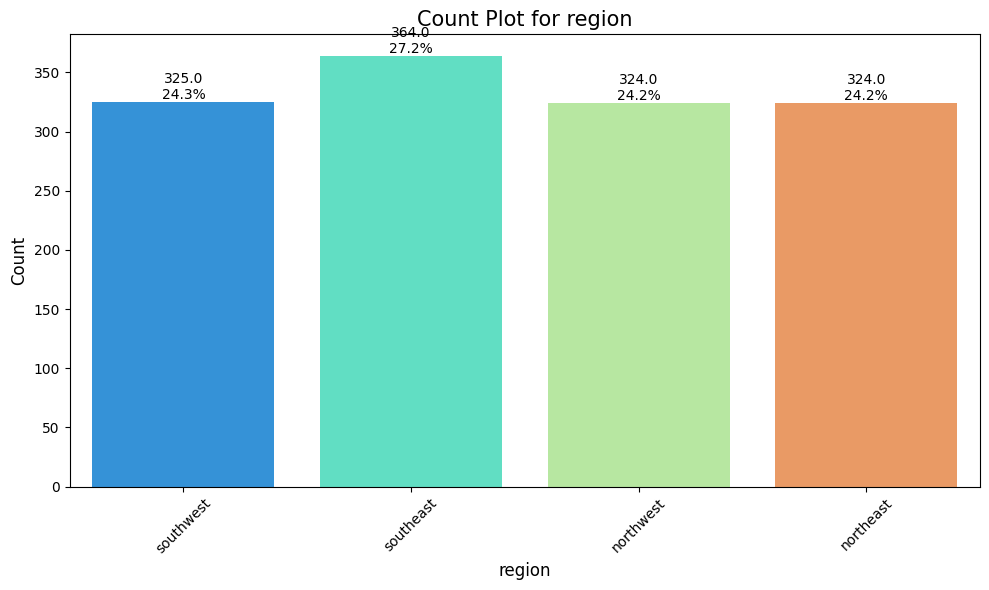

In [ ]:
for column in df.select_dtypes(include=['object']):
    plt.figure(figsize=(10, 6))
    ax = sb.countplot(x=column, data=df,palette='rainbow')

    # Add count and percentage annotations to each bar
    total = len(df[column])
    for p in ax.patches:
        percentage = '{:.1f}%'.format(100 * p.get_height() / total)
        count = p.get_height()
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(f'{count}\n{percentage}', (x, y), ha='center', va='bottom')

    plt.title(f'Count Plot for {column}', fontsize=15)
    plt.xlabel(column, fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
    plt.tight_layout()
    plt.show()

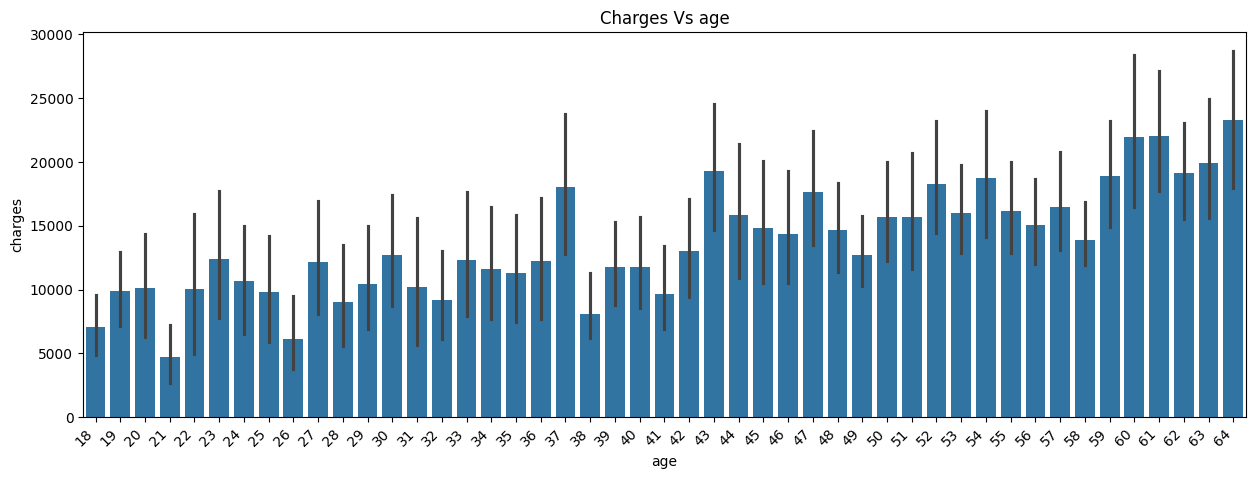

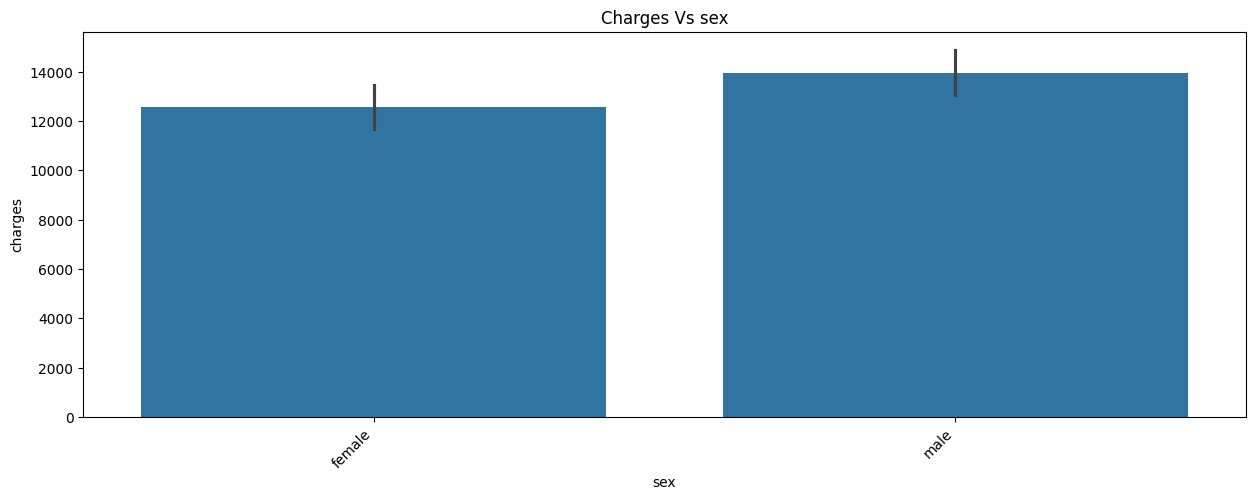

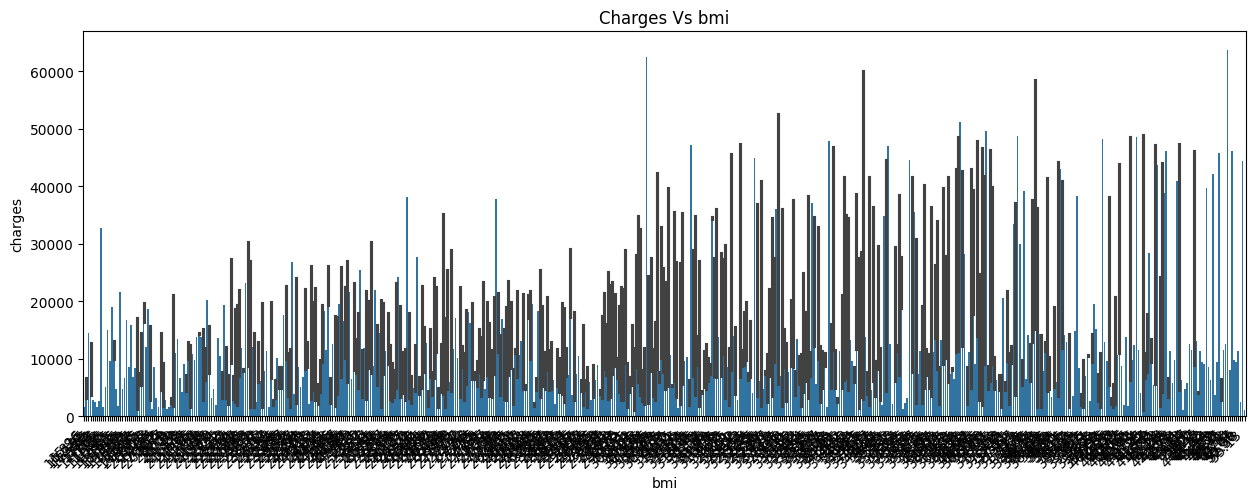

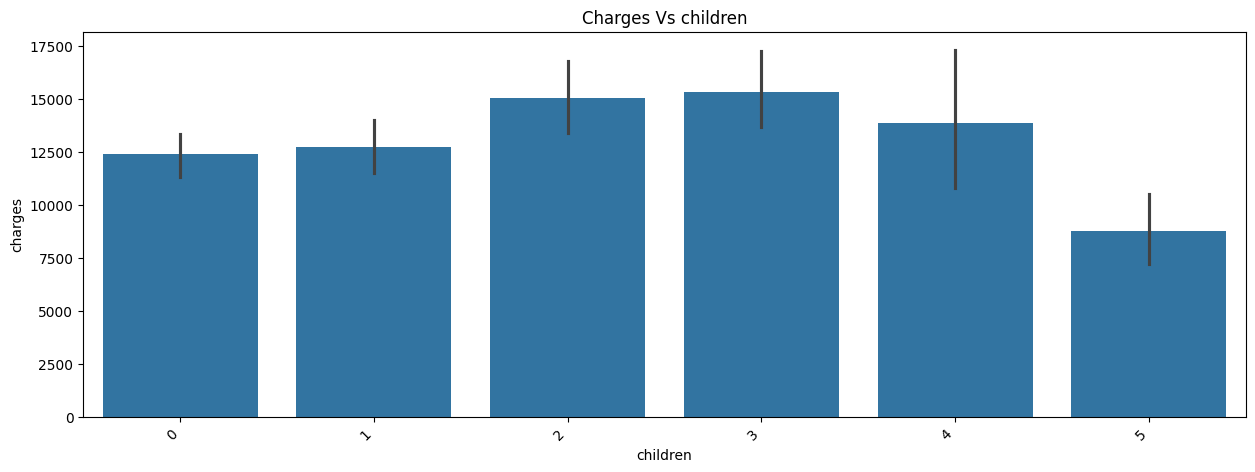

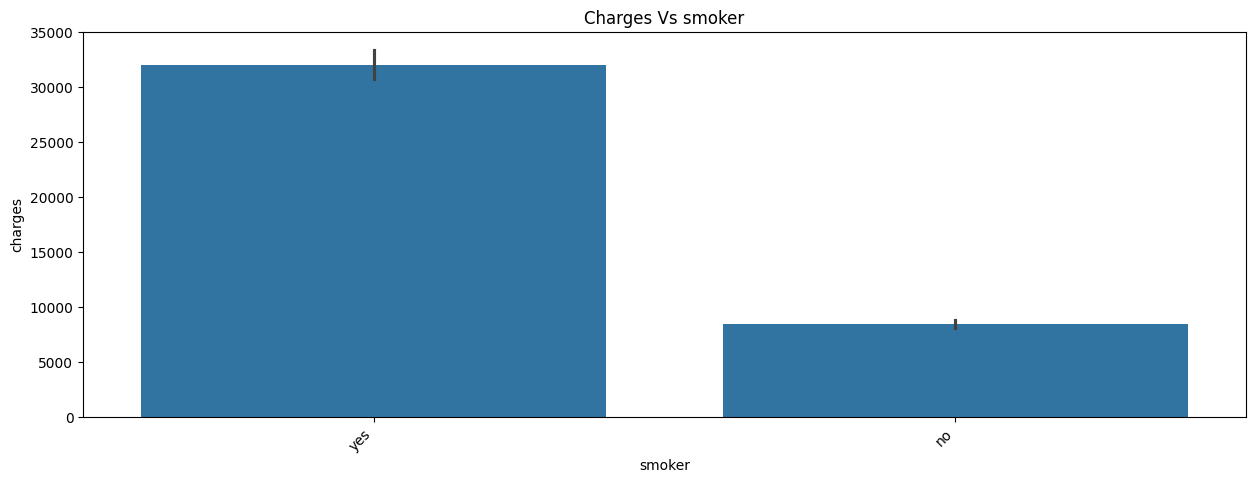

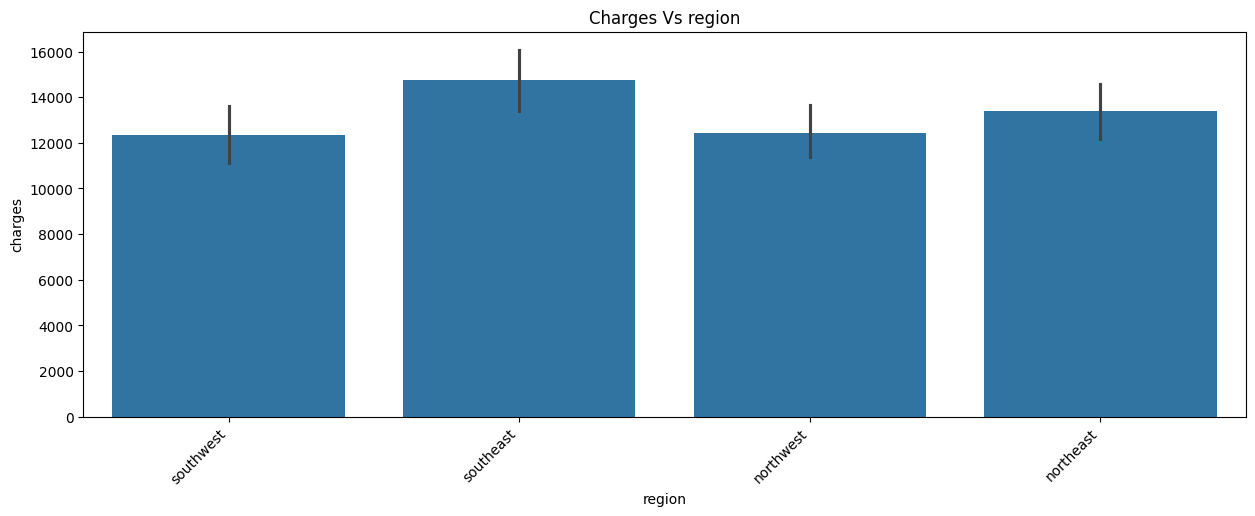

In [ ]:
#Bivariate
df1 = df.drop(columns='charges', axis=1)
for col in df1.columns:
  plt.figure(1, figsize=(15,5))
  title='Charges Vs '+col
  ax=sb.barplot(x=df1[col],y=df['charges']).set(title=title)
  plt.xticks(rotation=45,horizontalalignment='right');
  plt.show()


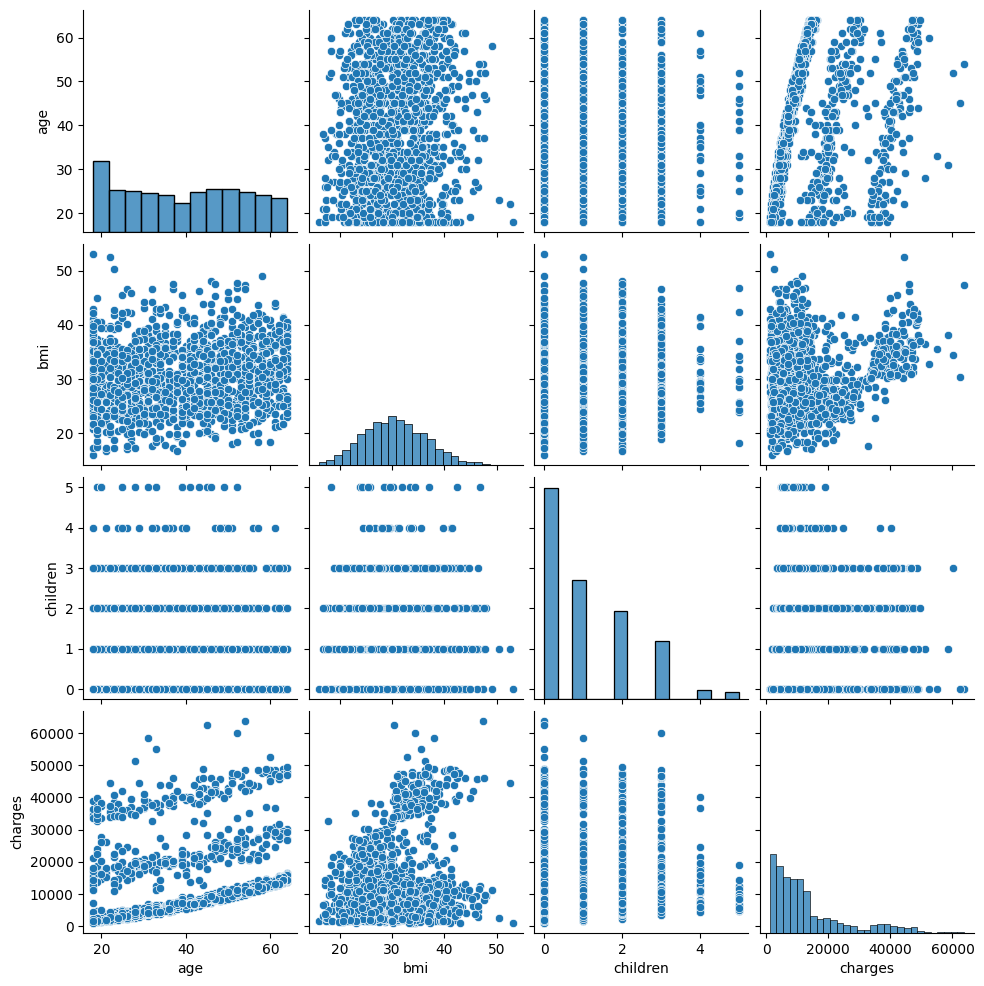

In [ ]:
sb.pairplot(df)
plt.show()

In [ ]:
#So Based on the above charts we come to the conclusiion that the charges are high in southeast region by comparing with all other feature

In [ ]:
#From the above chart it confirms that 5 to 10 male smokes and less than 5 female smokes under 18 years old

In [ ]:
#Target Visualization

<Axes: ylabel='charges'>

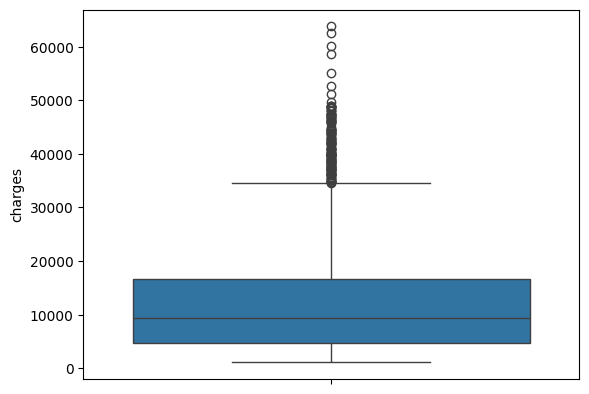

In [ ]:
sb.boxplot(df['charges'])

<Axes: xlabel='charges', ylabel='Count'>

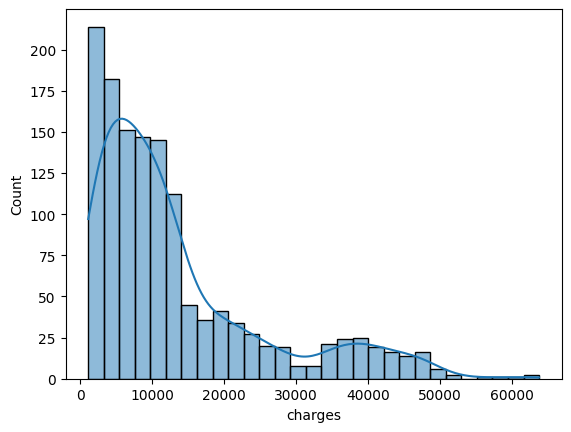

In [ ]:
sb.histplot(data=df,x=df['charges'],kde=True)

<Axes: xlabel='charges', ylabel='Count'>

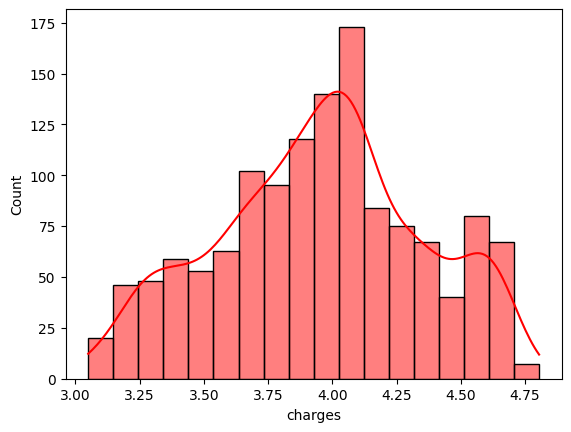

In [ ]:
sb.histplot(np.log10(df['charges']),kde=True, color = 'r')

In [ ]:
skew(df['charges'], axis=0, bias=True)

1.5136902413349014

In [ ]:
#Data Preprocessing

In [ ]:
df['sex'].value_counts()

sex
male      675
female    662
Name: count, dtype: int64

In [ ]:
df['smoker'].value_counts()

smoker
no     1063
yes     274
Name: count, dtype: int64

In [ ]:
df['region'].value_counts()

region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64

In [ ]:
#To encode the character data column to numerical value
label_encoder = preprocessing.LabelEncoder()
df['sex']= label_encoder.fit_transform(df['sex'])
df['smoker']= label_encoder.fit_transform(df['smoker'])
df['region']= label_encoder.fit_transform(df['region'])
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


<Axes: >

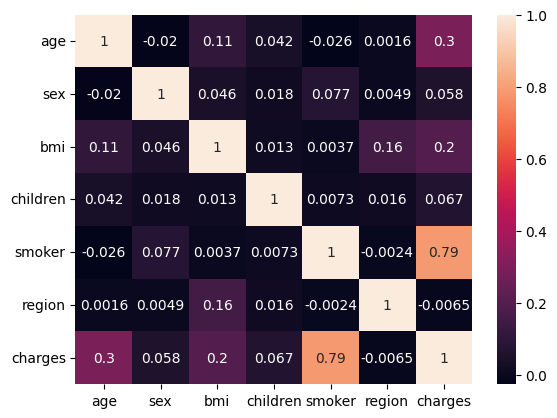

In [ ]:
sb.heatmap(df.corr(),annot=True)

In [ ]:
#From the above heatmap it is clear that we don't have correlated independent variables (i.e., Not more than 0.5) Ignore 0.79 since it is related with target variable

In [ ]:
X = df.drop(columns='charges', axis=1)
Y = df['charges']

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
#LinearREgression

In [ ]:
lr_model = LinearRegression()

In [ ]:
lr_model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr_model.predict(x_test)

In [ ]:
#Matrics

In [ ]:
lr_model.score(x_test,y_test)

0.8068466322629112

In [ ]:
r2_score(y_train, lr_model.predict(x_train))

0.7297182858804965

In [ ]:
r2_score(y_test, y_pred)

0.8068466322629112

In [ ]:
mean_squared_error(y_test, y_pred)

35493102.61165051

In [ ]:
mean_absolute_error(y_test, y_pred)

4182.353155288296

In [ ]:
#RandomForestRegression

In [ ]:
rf_model=RandomForestRegressor(n_estimators=50, max_depth=7)

In [ ]:
rf_model.fit(x_train,y_train)

RandomForestRegressor(max_depth=7, n_estimators=50)

In [ ]:
y_pred= rf_model.predict(x_test)

In [ ]:
#Matrics

In [ ]:
rf_model.score(x_test,y_test)

0.8911035500313785

In [ ]:
r2_score(y_train, rf_model.predict(x_train))

0.9201454035936821

In [ ]:
r2_score(y_test, y_pred)

0.8911035500313785

In [ ]:
mean_squared_error(y_test, y_pred)

20010383.034282375

In [ ]:
mean_absolute_error(y_test, y_pred)

2521.760770845027

In [ ]:
#KNeighborsRegressor

In [ ]:
knr_model=KNeighborsRegressor()

In [ ]:
knr_model.fit(x_train,y_train)

KNeighborsRegressor()

In [ ]:
y_pred= knr_model.predict(x_test)

In [ ]:
#Matrics

In [ ]:
knr_model.score(x_test,y_test)

0.054604301462178206

In [ ]:
r2_score(y_train, knr_model.predict(x_train))

0.412530940177563

In [ ]:
r2_score(y_test, y_pred)

0.054604301462178206

In [ ]:
mean_squared_error(y_test, y_pred)

173722192.52469587

In [ ]:
mean_absolute_error(y_test, y_pred)

8879.905009048507

In [ ]:
models = {
    "LR": LinearRegression(),
    "RF": RandomForestRegressor(n_estimators=100, max_depth=7),
    "DT": DecisionTreeRegressor(),
    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, max_depth=7),
    "KNN": KNeighborsRegressor(),
    "SVR": SVR()
}

In [ ]:
for name, model in models.items():
    print(f'Training Model {name} \n-----------------------------------------------')
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    print(f'Score is {model.score(x_test, y_test)}')

    print(f'Training R-squared: {r2_score(y_train, model.predict(x_train))}')
    print(f'Testing R-squared: {r2_score(y_test, y_pred)}')

    print(f'Mean Squared Error: {mean_squared_error(y_test, y_pred)}')
    print(f'Mean Absolute Error: {mean_absolute_error(y_test, y_pred)}')



Training Model LR 
-----------------------------------------------
Score is 0.8068466322629112
Training R-squared: 0.7297182858804965
Testing R-squared: 0.8068466322629112
Mean Squared Error: 35493102.61165051
Mean Absolute Error: 4182.353155288296
Training Model RF 
-----------------------------------------------
Score is 0.8941330599565086
Training R-squared: 0.9219029721928136
Testing R-squared: 0.8941330599565086
Mean Squared Error: 19453692.214467026
Mean Absolute Error: 2470.260053876602
Training Model DT 
-----------------------------------------------
Score is 0.7908107024389773
Training R-squared: 1.0
Testing R-squared: 0.7908107024389773
Mean Squared Error: 38439801.95933588
Mean Absolute Error: 2855.341086638059
Training Model GradientBoosting 
-----------------------------------------------
Score is 0.8687073158747972
Training R-squared: 0.9919550224428867
Testing R-squared: 0.8687073158747972
Mean Squared Error: 24125826.872238595
Mean Absolute Error: 2634.998329383513
Tra